In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2010-12-10 20:01:00')

In [5]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
}).reset_index()

In [6]:
rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

In [7]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [8]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2040.406712
std,1701.200176,96.860633,8.170213,8911.755977
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.187500
50%,15350.500000,53.000000,2.000000,701.615000
75%,16834.250000,136.000000,5.000000,1714.932500
max,18287.000000,374.000000,205.000000,349164.350000


In [9]:
rfm.to_csv(
    "../data/features/rfm_features.csv",
    index=False
)

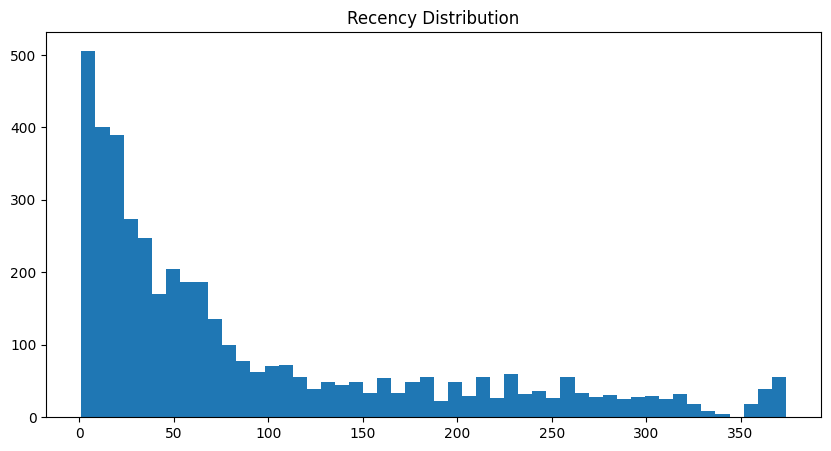

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(rfm["Recency"], bins=50)
plt.title("Recency Distribution")
plt.show()

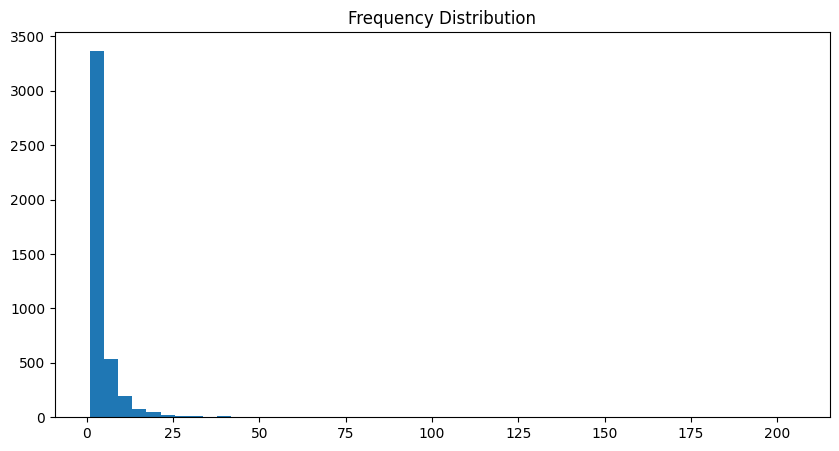

In [11]:
plt.figure(figsize=(10,5))
plt.hist(rfm["Frequency"], bins=50)
plt.title("Frequency Distribution")
plt.show()

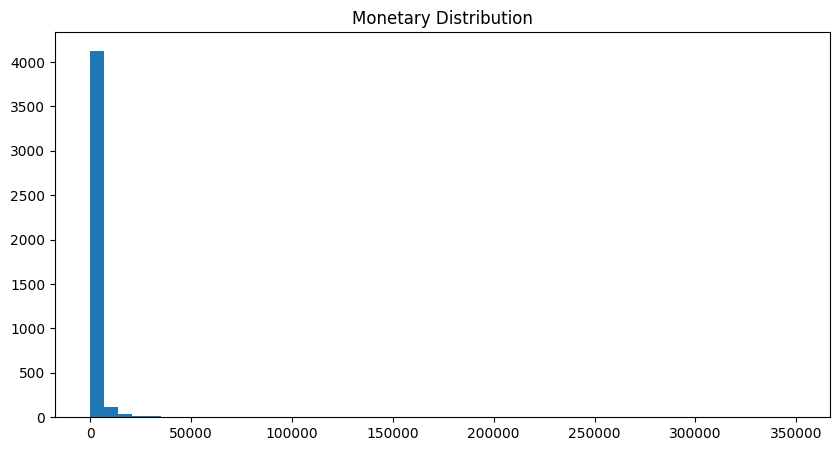

In [12]:
plt.figure(figsize=(10,5))
plt.hist(rfm["Monetary"], bins=50)
plt.title("Monetary Distribution")
plt.show()

In [13]:
rfm.shape

(4312, 4)

In [14]:
rfm.head()

rfm.shape

rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2040.406712
std,1701.200176,96.860633,8.170213,8911.755977
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.187500
50%,15350.500000,53.000000,2.000000,701.615000
75%,16834.250000,136.000000,5.000000,1714.932500
max,18287.000000,374.000000,205.000000,349164.350000
